## Imports and some constants

In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import time

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness
from keras.layers import LeakyReLU

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only these gestures
CONDITIONS = ['like', 'stop', 'peace']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

### Path to dataset
(!) Needs to be changed by the user

In [2]:
# path to HaGRID dataset - NOTE: this should be changed by the user depending on where the dataset is saved
DATASET_PATH = r'C:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\cnn-w5\gesture_dataset\gesture_dataset_sample'

## Helper function to load and parse annotations

In [3]:
annotations = dict()

for condition in CONDITIONS:
    with open(os.path.join(DATASET_PATH, '_annotations', f'{condition}.json')) as f:
        annotations[condition] = json.load(f)

In [4]:
def preprocess_image_new(img, color_space):
    img = cv2.cvtColor(img, color_space)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## Function to load images and annotations

In [5]:
def load_images(cs_code, color_channels):
    images = []
    labels = []
    label_names = []

    for condition in CONDITIONS:
        for filename in tqdm(os.listdir(os.path.join(DATASET_PATH, condition)), desc=condition):
            UID = filename.split('.')[0]
            img = cv2.imread(os.path.join(DATASET_PATH, condition, filename))
            if img is None:
                continue
            try:
                annotation = annotations[condition][UID]
            except:
                continue
            for i, bbox in enumerate(annotation['bboxes']):
                x1 = int(bbox[0] * img.shape[1])
                y1 = int(bbox[1] * img.shape[0])
                w  = int(bbox[2] * img.shape[1])
                h  = int(bbox[3] * img.shape[0])
                crop = img[y1:y1+h, x1:x1+w]
                preprocessed = preprocess_image_new(crop, cs_code)
                label = annotation['labels'][i]
                if label == "no_gesture":
                    continue
                if label not in label_names:
                    label_names.append(label)
                images.append(preprocessed)
                labels.append(label_names.index(label))

    return images, labels, label_names

## Split data set into train and test

In [6]:
def split_data(images, labels):
    X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

    print(len(X_train))
    print(len(X_test))
    print(len(y_train))
    print(len(y_test))

    return X_train, X_test, y_train, y_test

## Transform data sets into a format compatible with our neural network

In [7]:
def transform_data(X_train, X_test, y_train, y_test, color_channels):
    # image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]
    # furthermore, scale all values to a range of 0 to 1
    X_train = np.array(X_train).astype('float32') / 255.
    X_test  = np.array(X_test).astype('float32')  / 255.

    # training data has to be converted to a categorial vector ("one hot"):
    # [3] --> [0, 0, 0, 1, 0, ..., 0]
    train_label = to_categorical(y_train)
    test_label  = to_categorical(y_test)

    X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, color_channels)
    X_test  = X_test.reshape( -1, IMG_SIZE, IMG_SIZE, color_channels)

    print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

    return X_train, X_test, train_label, test_label

## Build model

In [8]:
def build_model(color_channels, num_classes):
    model = Sequential()

    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal', input_shape=(IMG_SIZE, IMG_SIZE, color_channels)))
    model.add(RandomContrast(0.1))

    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), activation='leaky_relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), activation='leaky_relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), activation='leaky_relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    # dropout layers can drop part of the data during each epoch - this prevents overfitting
    model.add(Dropout(0.2))

    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())

    # add some fully connected layers ("Dense")
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))

    # for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

    return model

## Train model

In [17]:
def train_model(model, X_train, train_label, X_test, test_label, y_test):
    # define callback functions that react to the model's behavior during training
    # in this example, we reduce the learning rate once we get stuck and early stopping
    # to cancel the training if there are no improvements for a certain amount of epochs
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
    stop_early = EarlyStopping(monitor='val_loss', patience=10)

    # train the model using the fit() function - this will take a while
    history = model.fit(
        X_train, train_label,
        batch_size=8,
        epochs=50,
        verbose=1,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr, stop_early]
    )

    # evaluate on test set
    val_loss, val_acc = model.evaluate(X_test, test_label, verbose=0)


    print(f"val_accuracy: {val_acc:.4f} | val_loss: {val_loss:.4f}")

    # predict on test set and build confusion matrix
    y_predictions = model.predict(X_test)
    y_predictions = np.argmax(y_predictions, axis=1)
    conf_matrix = confusion_matrix(y_test, y_predictions)

    return history, val_loss, val_acc, conf_matrix

## Putting it all together...

In [18]:
results = {}

cs_name = 'Grayscale'
cs_code = cv2.COLOR_BGR2GRAY
color_channels = 1

images, labels, label_names = load_images(cs_code, color_channels)

X_train, X_test, y_train, y_test = split_data(images, labels)

X_train, X_test, train_label, test_label = transform_data(X_train, X_test, y_train, y_test, color_channels)

model = build_model(color_channels, num_classes=len(label_names))

history, val_loss, val_acc, conf_matrix = train_model(model, X_train, train_label, X_test, test_label, y_test)

results[cs_name] = {
    'val_accuracy': val_acc,
    'val_loss': val_loss,
    'history': history.history,
    'conf_matrix': conf_matrix,
    'model': model
}

like:   0%|          | 0/250 [00:00<?, ?it/s]

stop:   0%|          | 0/250 [00:00<?, ?it/s]

peace:   0%|          | 0/250 [00:00<?, ?it/s]

600
150
600
150
(600, 64, 64, 1) (150, 64, 64, 1) (600, 3) (150, 3)
Epoch 1/50


c:\Users\Marti\Documents\Facultad\Regensburg\UR_Courses\ITT\assignment-05-cnn-martinarobyculasso\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3567 - loss: 1.1043 - val_accuracy: 0.3933 - val_loss: 1.0875 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4067 - loss: 1.0563 - val_accuracy: 0.4267 - val_loss: 1.1539 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5533 - loss: 0.8956 - val_accuracy: 0.6200 - val_loss: 0.8421 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7033 - loss: 0.7038 - val_accuracy: 0.7400 - val_loss: 0.6533 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8183 - loss: 0.4757 - val_accuracy: 0.8667 - val_loss: 0.3896 - learning_rate: 0.0010
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8650 - loss: 0.3361 - val_accuracy: 0.9133 - val_loss: 0.2801 - learning_rate: 0.0010
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9083 - loss: 0.2545 - val_accuracy: 0.8933 - v

## Result visualization

### Training history

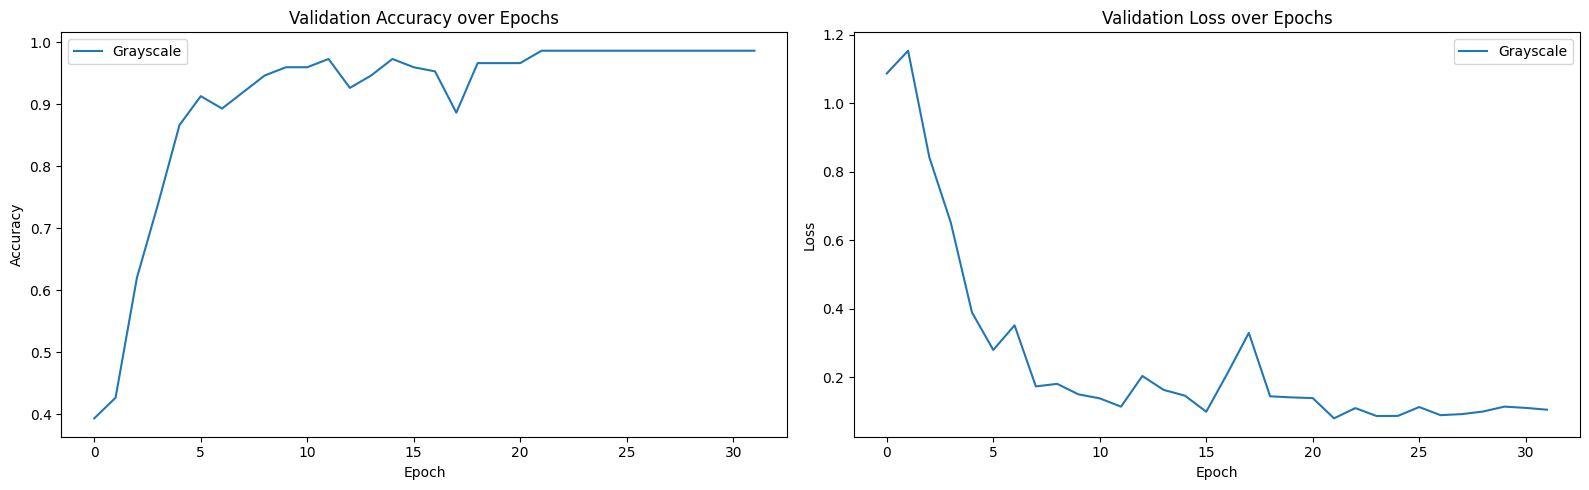

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cs_name, res in results.items():
    axes[0].plot(res['history']['val_accuracy'], label=cs_name)
    axes[1].plot(res['history']['val_loss'],     label=cs_name)

axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validation Loss over Epochs')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### Confusion matrix

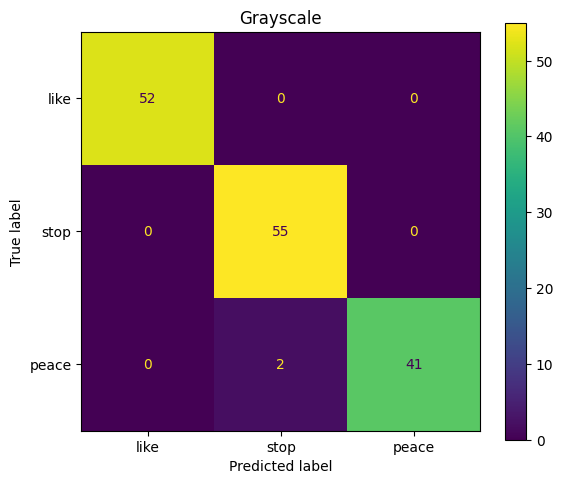

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay(results['Grayscale']['conf_matrix'], display_labels=label_names).plot(ax=ax)
ax.set_title('Grayscale')
plt.tight_layout()
plt.show()

## Save model

In [24]:
for cs_name, res in results.items():
    res['model'].save(f'model_{cs_name.lower()}.keras')